# 01 — Univariate Analysis
**FoodHub Order Analysis**

This notebook examines each relevant variable **one at a time** to understand its
distribution, central tendency, spread, and any skew or anomalies. It sets the
foundation for the bivariate and multivariate analysis that follows.

Data source: `../data/processed/foodhub_analytical_clean.csv` (1,898 orders,
cleaned per the approved plan in Section 2.6).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv("../data/processed/foodhub_analytical_clean.csv")
print("Shape:", df.shape)
df.head()

Shape: (1898, 23)


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_fulfillment_time,...,rating_value,is_promoter,is_weekend,cost_band,customer_order_count,is_repeat_customer,restaurant_order_count,cuisine_order_count,cuisine_grouped,is_low_volume_restaurant
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,45,...,NaN,False,True,High,2,True,2,13,Other,True
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,48,...,NaN,False,True,Low,1,False,29,470,Japanese,False
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,51,...,5.0,True,False,Medium,1,False,16,77,Mexican,False
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,40,...,3.0,False,True,High,2,True,96,584,American,False
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,49,...,4.0,True,False,Low,3,True,4,584,American,False


In [2]:
# Quick reference: dtypes and the columns we will profile
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  1898 non-null   int64  
 1   customer_id               1898 non-null   int64  
 2   restaurant_name           1898 non-null   str    
 3   cuisine_type              1898 non-null   str    
 4   cost_of_the_order         1898 non-null   float64
 5   day_of_the_week           1898 non-null   str    
 6   rating                    1898 non-null   str    
 7   food_preparation_time     1898 non-null   int64  
 8   delivery_time             1898 non-null   int64  
 9   total_fulfillment_time    1898 non-null   int64  
 10  prep_time_share           1898 non-null   float64
 11  delivery_time_share       1898 non-null   float64
 12  rating_given              1898 non-null   bool   
 13  rating_value              1162 non-null   float64
 14  is_promoter        

## 1. Numeric variables — summary statistics
The four core numeric measures: order cost and the three time metrics
(prep, delivery, and their sum `total_fulfillment_time`).

In [3]:
num_cols = ["cost_of_the_order", "food_preparation_time",
            "delivery_time", "total_fulfillment_time"]
df[num_cols].describe().round(2)

,cost_of_the_order,food_preparation_time,delivery_time,total_fulfillment_time
count,1898.00,1898.00,1898.00,1898.00
mean,16.50,27.37,24.16,51.53
std,7.48,4.63,4.97,6.83
min,4.47,20.00,15.00,35.00
25%,12.08,23.00,20.00,47.00
50%,14.14,27.00,25.00,52.00
75%,22.30,31.00,28.00,56.00
max,35.41,35.00,33.00,68.00


## 2. Distribution of order cost
How much do customers spend per order? Cost is a direct proxy for FoodHub's
commission revenue (KPI 3).

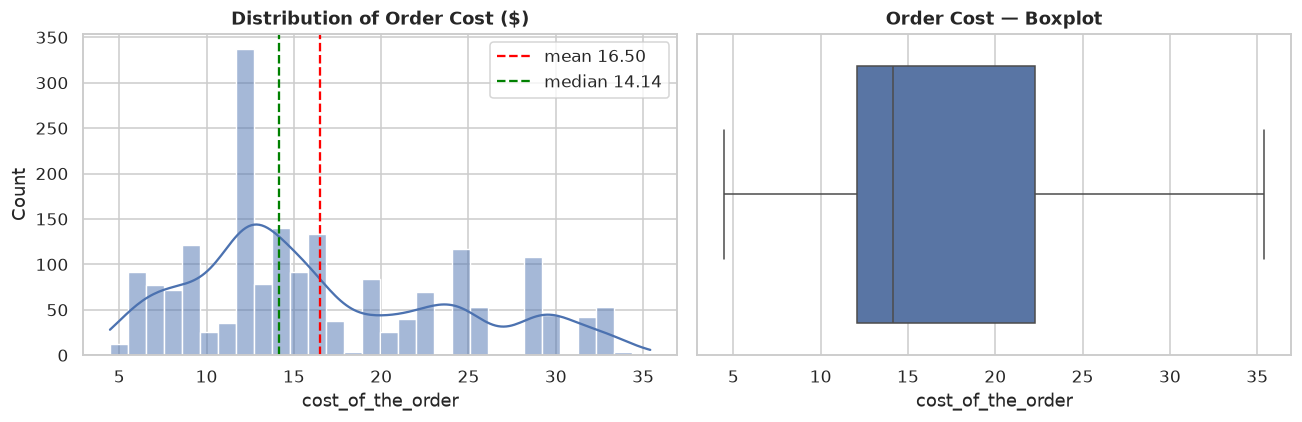

skew = 0.62


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["cost_of_the_order"], bins=30, kde=True, color="#4C72B0", ax=ax[0])
ax[0].axvline(df["cost_of_the_order"].mean(), color="red", ls="--", label=f"mean {df['cost_of_the_order'].mean():.2f}")
ax[0].axvline(df["cost_of_the_order"].median(), color="green", ls="--", label=f"median {df['cost_of_the_order'].median():.2f}")
ax[0].set_title("Distribution of Order Cost ($)"); ax[0].set_xlabel("cost_of_the_order"); ax[0].legend()
sns.boxplot(x=df["cost_of_the_order"], color="#4C72B0", ax=ax[1])
ax[1].set_title("Order Cost — Boxplot"); ax[1].set_xlabel("cost_of_the_order")
plt.tight_layout(); plt.show()
print(f"skew = {df['cost_of_the_order'].skew():.2f}")

**Read-out:** Order cost is **right-skewed** (mean \$16.50 > median \$14.14).
Most orders cluster in the \$10–\$15 range, with a lighter tail of higher-value
orders up to \$35.41. No outliers beyond the natural range — spend is modest and
concentrated at the low end.

## 3. Distribution of the time metrics
Preparation time, delivery time, and total fulfillment time (the full customer
wait — KPI 1).

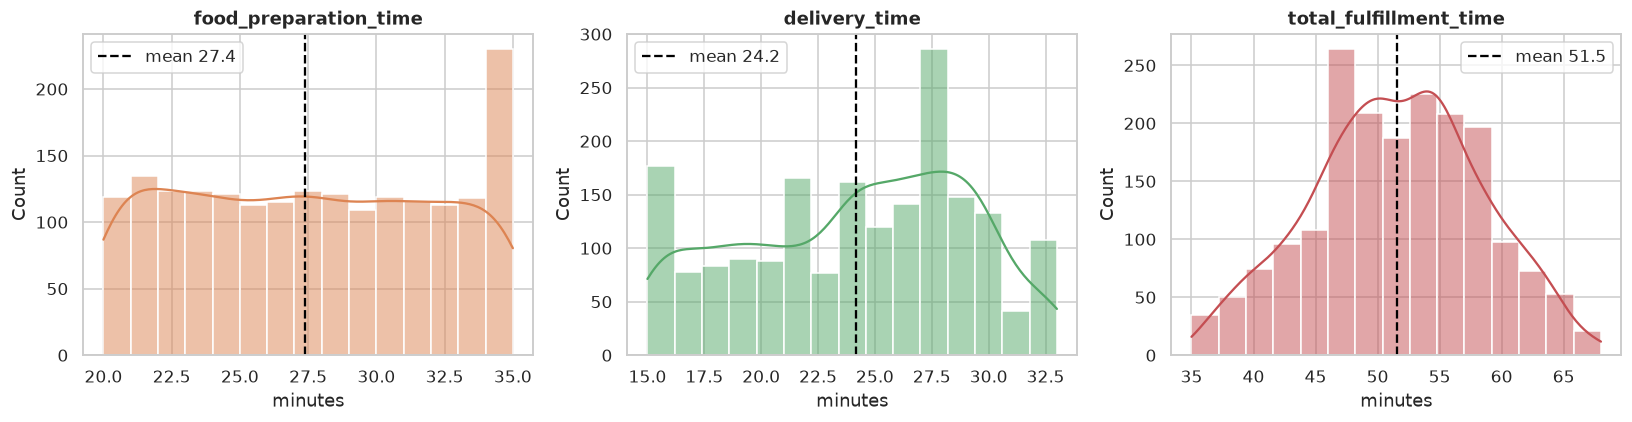

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
specs = [("food_preparation_time", "#DD8452"),
         ("delivery_time", "#55A868"),
         ("total_fulfillment_time", "#C44E52")]
for a, (col, c) in zip(ax, specs):
    sns.histplot(df[col], bins=15, kde=True, color=c, ax=a)
    a.axvline(df[col].mean(), color="black", ls="--", label=f"mean {df[col].mean():.1f}")
    a.set_title(f"{col}"); a.set_xlabel("minutes"); a.legend()
plt.tight_layout(); plt.show()

**Read-out:**
- **Prep time** spans 20–35 min (mean ~27), fairly uniform — kitchens vary but stay in a tight band.
- **Delivery time** spans 15–33 min (mean ~24), roughly symmetric.
- **Total fulfillment time** spans 35–68 min (mean ~51.5). The typical customer waits
  just under an hour end-to-end. Both components contribute meaningfully, with prep
  slightly the larger share.

## 4. Customer ratings — including the "Not given" story
Ratings drive KPI 2. Recall ~39% of orders were never rated.

/tmp/ipykernel_2562/578286782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#999999", "#C44E52", "#DD8452", "#55A868"], ax=ax[0])
/tmp/ipykernel_2562/578286782.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rc.index.astype(int).astype(str), y=rc.values, palette=["#C44E52", "#DD8452", "#55A868"], ax=ax[1])


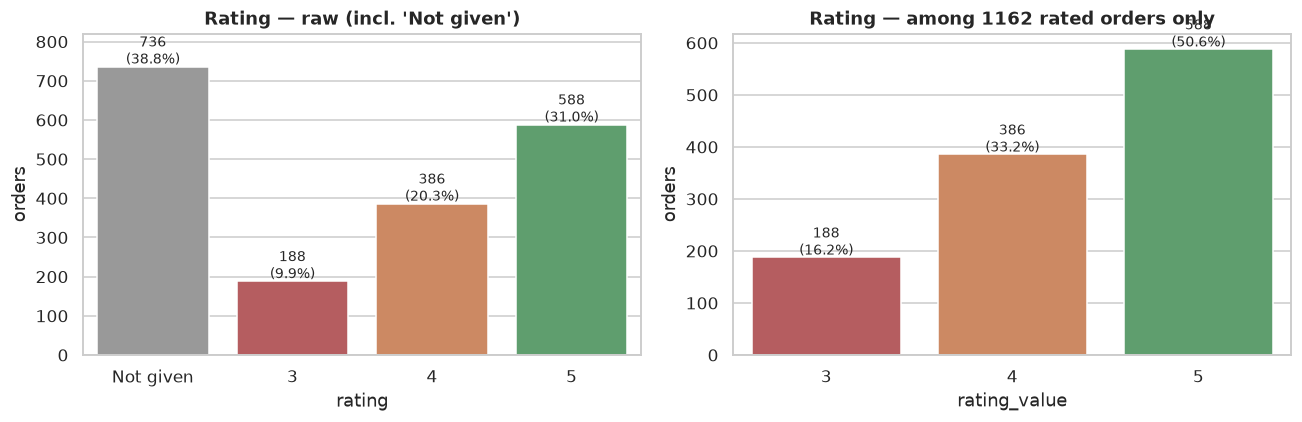

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# 4a: raw rating including 'Not given'
order = ["Not given", "3", "4", "5"]
counts = df["rating"].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, palette=["#999999", "#C44E52", "#DD8452", "#55A868"], ax=ax[0])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 8, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
ax[0].set_title("Rating — raw (incl. 'Not given')"); ax[0].set_ylabel("orders"); ax[0].set_ylim(0, 820)
# 4b: among rated orders only
rated = df["rating_value"].dropna()
rc = rated.value_counts().sort_index()
sns.barplot(x=rc.index.astype(int).astype(str), y=rc.values, palette=["#C44E52", "#DD8452", "#55A868"], ax=ax[1])
for i, v in enumerate(rc.values):
    ax[1].text(i, v + 5, f"{v}\n({v/len(rated)*100:.1f}%)", ha="center", fontsize=9)
ax[1].set_title(f"Rating — among {len(rated)} rated orders only"); ax[1].set_ylabel("orders")
plt.tight_layout(); plt.show()

**Read-out:** The single biggest bar is **"Not given" (38.8%)** — the dominant
data story. Among the 1,162 customers who *did* rate, scores are strongly positive:
**~51% gave 5, ~33% gave 4, ~16% gave 3**, and no 1s or 2s appear at all. This is a
classic ceiling/selection effect: the service looks excellent, but only from
self-selected raters, so satisfaction figures should always be read with the low
response rate in mind.

## 5. Cuisine frequency
Which cuisines are ordered most? (Frequency of a categorical variable — demand mix.)

/tmp/ipykernel_2562/4033733491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=cc.index, x=cc.values, palette="viridis", ax=ax)


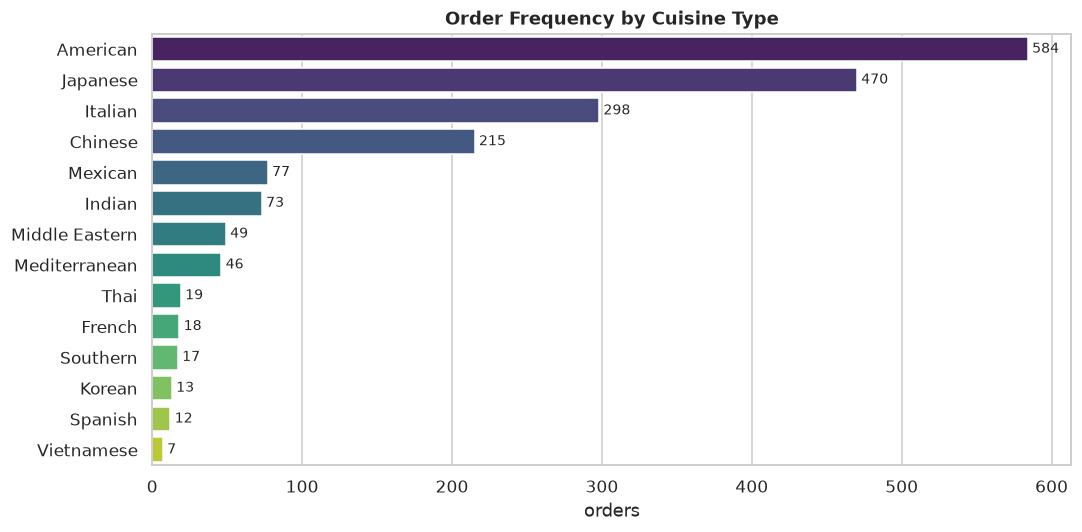

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
cc = df["cuisine_type"].value_counts()
sns.barplot(y=cc.index, x=cc.values, palette="viridis", ax=ax)
for i, v in enumerate(cc.values):
    ax.text(v + 3, i, str(v), va="center", fontsize=9)
ax.set_title("Order Frequency by Cuisine Type"); ax.set_xlabel("orders"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Read-out:** Demand is **top-heavy**. **American (584)** and **Japanese (470)**
alone are ~56% of all orders; add **Italian (298)** and **Chinese (215)** and the top
four cover ~83%. The remaining ten cuisines are a long tail — six of them under 20
orders (grouped as "Other" in `cuisine_grouped`).

## 6. Weekday vs weekend order volume
When are orders placed? (`day_of_the_week` — only two levels available.)

/tmp/ipykernel_2562/1987484761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dc.index, y=dc.values, palette=["#4C72B0", "#DD8452"], ax=ax)


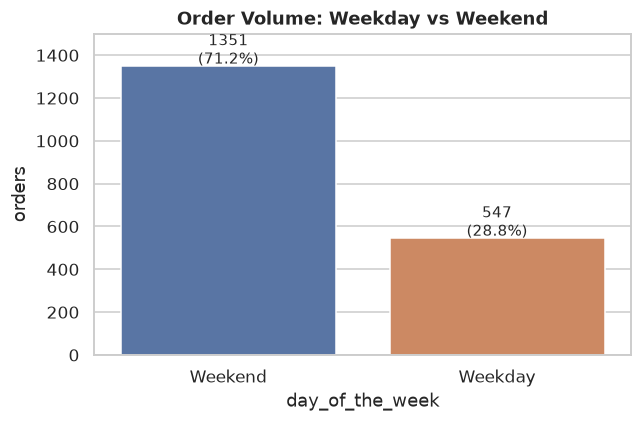

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
dc = df["day_of_the_week"].value_counts()
sns.barplot(x=dc.index, y=dc.values, palette=["#4C72B0", "#DD8452"], ax=ax)
for i, v in enumerate(dc.values):
    ax.text(i, v + 10, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
ax.set_title("Order Volume: Weekday vs Weekend"); ax.set_ylabel("orders"); ax.set_ylim(0, 1500)
plt.tight_layout(); plt.show()

**Read-out:** Orders are heavily **weekend-skewed: 1,351 (71.2%) weekend vs
547 (28.8%) weekday**. Weekend demand is ~2.5x weekday demand — an operational signal
(staffing, driver capacity) and the backdrop for Hypothesis 1.

## 7. Top restaurants by order volume
Which venues drive demand? (178 restaurants — showing the top 15.)

/tmp/ipykernel_2562/4024308302.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top.index, x=top.values, palette="mako", ax=ax)


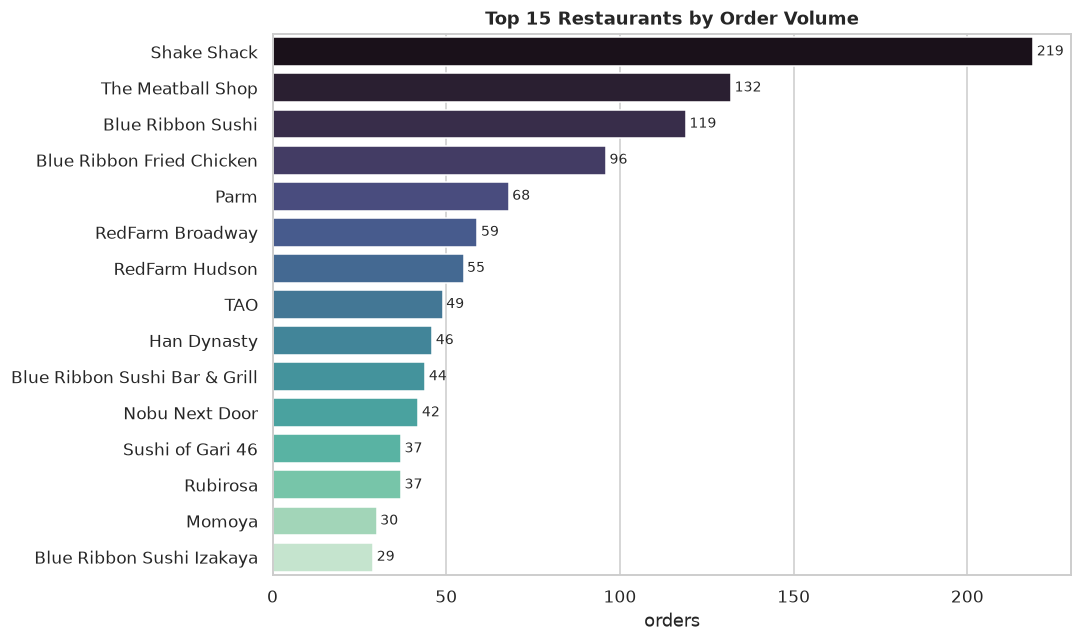

Top 5 restaurants account for 634 orders (33.4% of all orders)


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
top = df["restaurant_name"].value_counts().head(15)
sns.barplot(y=top.index, x=top.values, palette="mako", ax=ax)
for i, v in enumerate(top.values):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)
ax.set_title("Top 15 Restaurants by Order Volume"); ax.set_xlabel("orders"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
print("Top 5 restaurants account for",
      f"{df['restaurant_name'].value_counts().head(5).sum()} orders "
      f"({df['restaurant_name'].value_counts().head(5).sum()/len(df)*100:.1f}% of all orders)")

**Read-out:** Demand is **extremely concentrated**. **Shake Shack (219)** dwarfs
the field, followed by The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried
Chicken, and Parm. The **top 5 restaurants alone carry ~33% of all orders**, while
96 of 178 restaurants have ≤3 orders each — direct evidence for the concentration
theme in Hypothesis 3.

## 8. Cost bands
The engineered `cost_band` (Low / Medium / High tertiles) — a quick view of the
spend tiers used later.

/tmp/ipykernel_2562/2577196683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cb.index, y=cb.values, palette="crest", ax=ax)


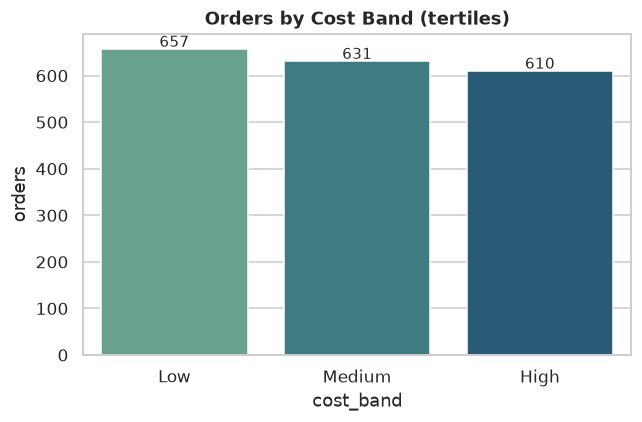

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
cb = df["cost_band"].value_counts().reindex(["Low", "Medium", "High"])
sns.barplot(x=cb.index, y=cb.values, palette="crest", ax=ax)
for i, v in enumerate(cb.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=10)
ax.set_title("Orders by Cost Band (tertiles)"); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()

**Read-out:** By construction the tertiles are near-balanced (Low 657, Medium
631, High 610), giving three comparably-sized spend segments for downstream analysis.

## Univariate summary
- **Cost:** right-skewed, most orders \$10–\$15 (mean \$16.50); modest basket sizes.
- **Times:** total wait ~51.5 min on average; prep (20–35) and delivery (15–33) both
  contribute, no outliers.
- **Ratings:** the headline is **38.8% "Not given"**; where rated, sentiment is very
  positive (only 3–5, mostly 4–5) — selection bias applies.
- **Cuisine:** top-heavy — American + Japanese ≈ 56% of orders.
- **Timing:** ~71% of orders on weekends.
- **Restaurants:** highly concentrated — top 5 ≈ 33% of orders; long tail of tiny venues.

These distributions motivate the hypotheses: weekend load (H1), speed↔rating (H2),
and demand/revenue concentration (H3).

---
## 9. Question: distribution of retention across customer cohorts

> *"What is the distribution of retention across different customer cohorts
> (e.g., first-month users vs later-month users)?"*

**Data limitation (must be stated first).** This question assumes two things this
dataset does **not** contain:
1. **A time axis** — there is *no order date/timestamp*, only a Weekday/Weekend flag
   (gap G1). Without dates we cannot place customers into *time-based cohorts* such as
   "first-month" vs "later-month" users.
2. **A retention definition** — "retention" requires observing whether a customer
   returns in a *later period*. With no dates, a returning-within-a-window concept
   cannot be constructed (gap G3).

So the literal question **cannot be answered as written**. The closest meaningful,
data-supported equivalent is the **distribution of customers by how many times they
ordered** — i.e. **one-time vs repeat customers** — which is the nearest available
proxy for loyalty/retention. We answer that below.

In [11]:
# Orders per customer -> the loyalty proxy
cust_orders = df.groupby("customer_id")["order_id"].count()
n_customers = cust_orders.shape[0]

one_time = (cust_orders == 1).sum()
repeat = (cust_orders > 1).sum()
orders_from_repeat = df["is_repeat_customer"].sum()

print(f"Total customers            : {n_customers}")
print(f"One-time customers (1 order): {one_time}  ({one_time/n_customers*100:.1f}%)")
print(f"Repeat customers   (>1)     : {repeat}  ({repeat/n_customers*100:.1f}%)")
print(f"Mean orders / customer      : {cust_orders.mean():.2f}  (median {cust_orders.median():.0f}, max {cust_orders.max()})")
print(f"Orders placed by repeat customers: {int(orders_from_repeat)} "
      f"({orders_from_repeat/len(df)*100:.1f}% of all orders)")

Total customers            : 1200
One-time customers (1 order): 784  (65.3%)
Repeat customers   (>1)     : 416  (34.7%)
Mean orders / customer      : 1.58  (median 1, max 13)
Orders placed by repeat customers: 1114 (58.7% of all orders)


/tmp/ipykernel_2562/4267873577.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.index, y=seg.values, palette=["#C44E52", "#55A868"], ax=ax[0])
/tmp/ipykernel_2562/4267873577.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.index.astype(int), y=dist.values, palette="viridis", ax=ax[1])


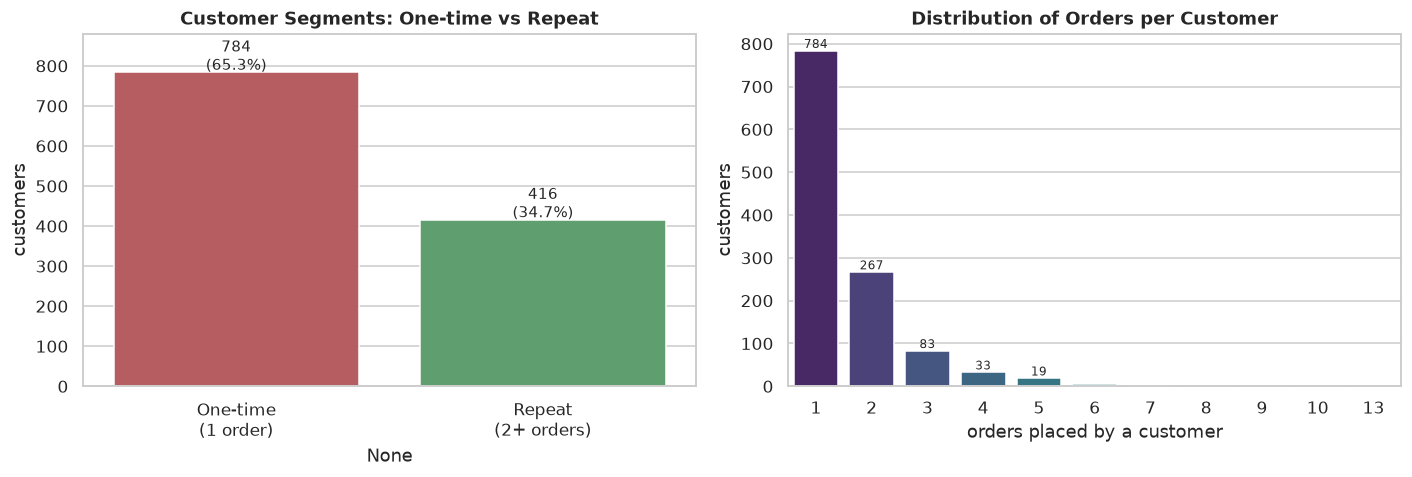

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# 9a: one-time vs repeat customers (the 'cohort' proxy)
seg = pd.Series({"One-time\n(1 order)": one_time, "Repeat\n(2+ orders)": repeat})
sns.barplot(x=seg.index, y=seg.values, palette=["#C44E52", "#55A868"], ax=ax[0])
for i, v in enumerate(seg.values):
    ax[0].text(i, v + 6, f"{v}\n({v/n_customers*100:.1f}%)", ha="center", fontsize=10)
ax[0].set_title("Customer Segments: One-time vs Repeat"); ax[0].set_ylabel("customers"); ax[0].set_ylim(0, 880)

# 9b: full distribution of orders-per-customer
dist = cust_orders.value_counts().sort_index()
sns.barplot(x=dist.index.astype(int), y=dist.values, palette="viridis", ax=ax[1])
for i, v in enumerate(dist.values):
    if v > 10: ax[1].text(i, v + 6, str(v), ha="center", fontsize=8)
ax[1].set_title("Distribution of Orders per Customer"); ax[1].set_xlabel("orders placed by a customer"); ax[1].set_ylabel("customers")
plt.tight_layout(); plt.show()

**Read-out (adapted question):**
- **~65.3% of customers are one-time** (784 of 1,200); **~34.7% are repeat** (416).
- The orders-per-customer distribution is **steeply right-skewed**: most place a
  single order, a meaningful minority place 2–3, and a very thin tail goes up to a
  single customer with **13 orders**. Mean = 1.58 orders/customer (median 1).
- Despite being a minority of *people*, **repeat customers generate 58.7% of all
  orders** — the loyal core is disproportionately valuable.

**Caveat:** Because there is no time axis, this is a *lifetime frequency* view, not a
true retention curve. It cannot tell us *when* customers return or whether early
customers stay engaged over time — that would require order timestamps (a
recommended future data addition).